Final Project Step 3 - Statistical Analysis 
Name: Gahyun Lim (Josie)

Research Question (1): To identify food items or food groups that are associated with circulating delta-valerobetaine (VB) levels.

(1)-1 Continuous Food Variables (Spearman Correlation)

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr

In [2]:
file_path = r"C:\Users\User\OneDrive - Emory University\Documents\GitHub\BIOS-584\Final Project - Josie\Continuous.xlsx"
data = pd.read_excel(file_path)

foods = [c for c in data.columns if c != "VB"]

results = {
    "Food": [],
    "Correlation": [],
    "p-value": []
}

for f in foods:
    x = pd.to_numeric(data[f], errors="coerce")
    y = pd.to_numeric(data["VB"], errors="coerce")
    
    valid = x.notna() & y.notna()
    corr, pval = spearmanr(y[valid], x[valid])

    results["Food"].append(f)
    results["Correlation"].append(corr)
    results["p-value"].append(pval)

pd.DataFrame(results).to_excel("Continuous_Food.xlsx", index=False)

(1)-2 Categorical Food Variables (Kruskal–Wallis, Wilcoxon Rank-Sum Test)

In [3]:
import pandas as pd
import numpy as np
from scipy.stats import kruskal, mannwhitneyu
import itertools 

In [6]:
file_path = r"C:\Users\User\OneDrive - Emory University\Documents\GitHub\BIOS-584\Final Project - Josie\Categorical.xlsx"
data = pd.read_excel(file_path)
data.columns = data.columns.str.strip()
foods = [c for c in data.columns if c not in ["VB", "ID"]]
rows = []

for food in foods:
    foodgroups = data[food]
    cats = foodgroups.dropna().unique() 

    if len(cats) < 2:
        continue

    kw_data = [data.loc[foodgroups == g, "VB"].dropna() for g in cats]
    _, kw_p = kruskal(*kw_data)

    for g1, g2 in itertools.combinations(cats, 2):
        vb1 = data.loc[foodgroups == g1, "VB"].dropna()
        vb2 = data.loc[foodgroups == g2, "VB"].dropna()

        if len(vb1) > 0 and len(vb2) > 0:
            _, p = mannwhitneyu(vb1, vb2, alternative="two-sided")
        else:
            p = np.nan

        rows.append({
            "Food": food,
            "Kruskal-Wallis, p-value": kw_p,
            "Categorical Pairs": f"{g1} vs {g2}",
            "Wilcoxon, p-value": p
        })

results = pd.DataFrame(rows)
results.to_excel("Categorical_Food.xlsx", index=False)

Research Question (2): To examine whether the associations between circulating VB and the identified food items/groups differ across age groups.

The data have been reorganized for clarity, including only the significant (p < 0.05) food items/groups: 'Continuous_Significant' and 'Categorical_Significant'. All non-relevant food items/groups, such as supplements, were removed. Information on sex and age has also been added for each entry.

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
import matplotlib.pyplot as plt

(2)-1 Significant Continuous Food Variables (Descriptive Analysis, Ordinary Least Squares Linear Regression)

In [116]:
file_path = r"C:\Users\User\OneDrive - Emory University\Documents\GitHub\BIOS-584\Final Project - Josie\Continuous_Significant.xlsx"
data = pd.read_excel(file_path)
exclude = ['ID', 'VB', 'AGE', 'SEX']
foods = [c for c in data.columns if c not in exclude]

In [117]:
data['AGE_GROUP'] = pd.cut(data['AGE'], bins=[0, 50, 100], labels=['Middle', 'Old'])

In [118]:
Continuous_Descriptive_Analysis = []

for food in foods:
    for age_group in data['AGE_GROUP'].unique():
        subset = data[data['AGE_GROUP'] == age_group].copy()
        subset = subset.dropna(subset=[food])
        
        if len(subset) > 0:
            median = subset[food].median()
            q1 = subset[food].quantile(0.25)
            q3 = subset[food].quantile(0.75)
            
            Continuous_Descriptive_Analysis.append({
                'Food': food,
                'AGE_GROUP': age_group,
                'Median_IQR': f"{median:.2f} [{q1:.2f}, {q3:.2f}]",
            })

Continuous_Descriptive_Analysis = pd.DataFrame(Continuous_Descriptive_Analysis)
print(Continuous_Descriptive_Analysis)
Continuous_Descriptive_Analysis.to_excel("Continuous_Descriptive_Analysis.xlsx", index=False)

                 Food AGE_GROUP         Median_IQR
0            PSVEGOTH    Middle  1.00 [0.67, 1.46]
1            PSVEGOTH       Old  1.11 [0.74, 1.62]
2              PSGTOT    Middle  4.27 [3.13, 7.20]
3              PSGTOT       Old  4.08 [3.01, 5.70]
4             PSDAIRY    Middle  0.81 [0.46, 1.15]
..                ...       ...                ...
93              TACOS       Old  0.03 [0.01, 0.06]
94  TEASUGARTEASPOONS    Middle  1.00 [1.00, 2.00]
95  TEASUGARTEASPOONS       Old  1.00 [1.00, 1.00]
96         WATERMELON    Middle  0.08 [0.02, 0.29]
97         WATERMELON       Old  0.07 [0.01, 0.16]

[98 rows x 3 columns]


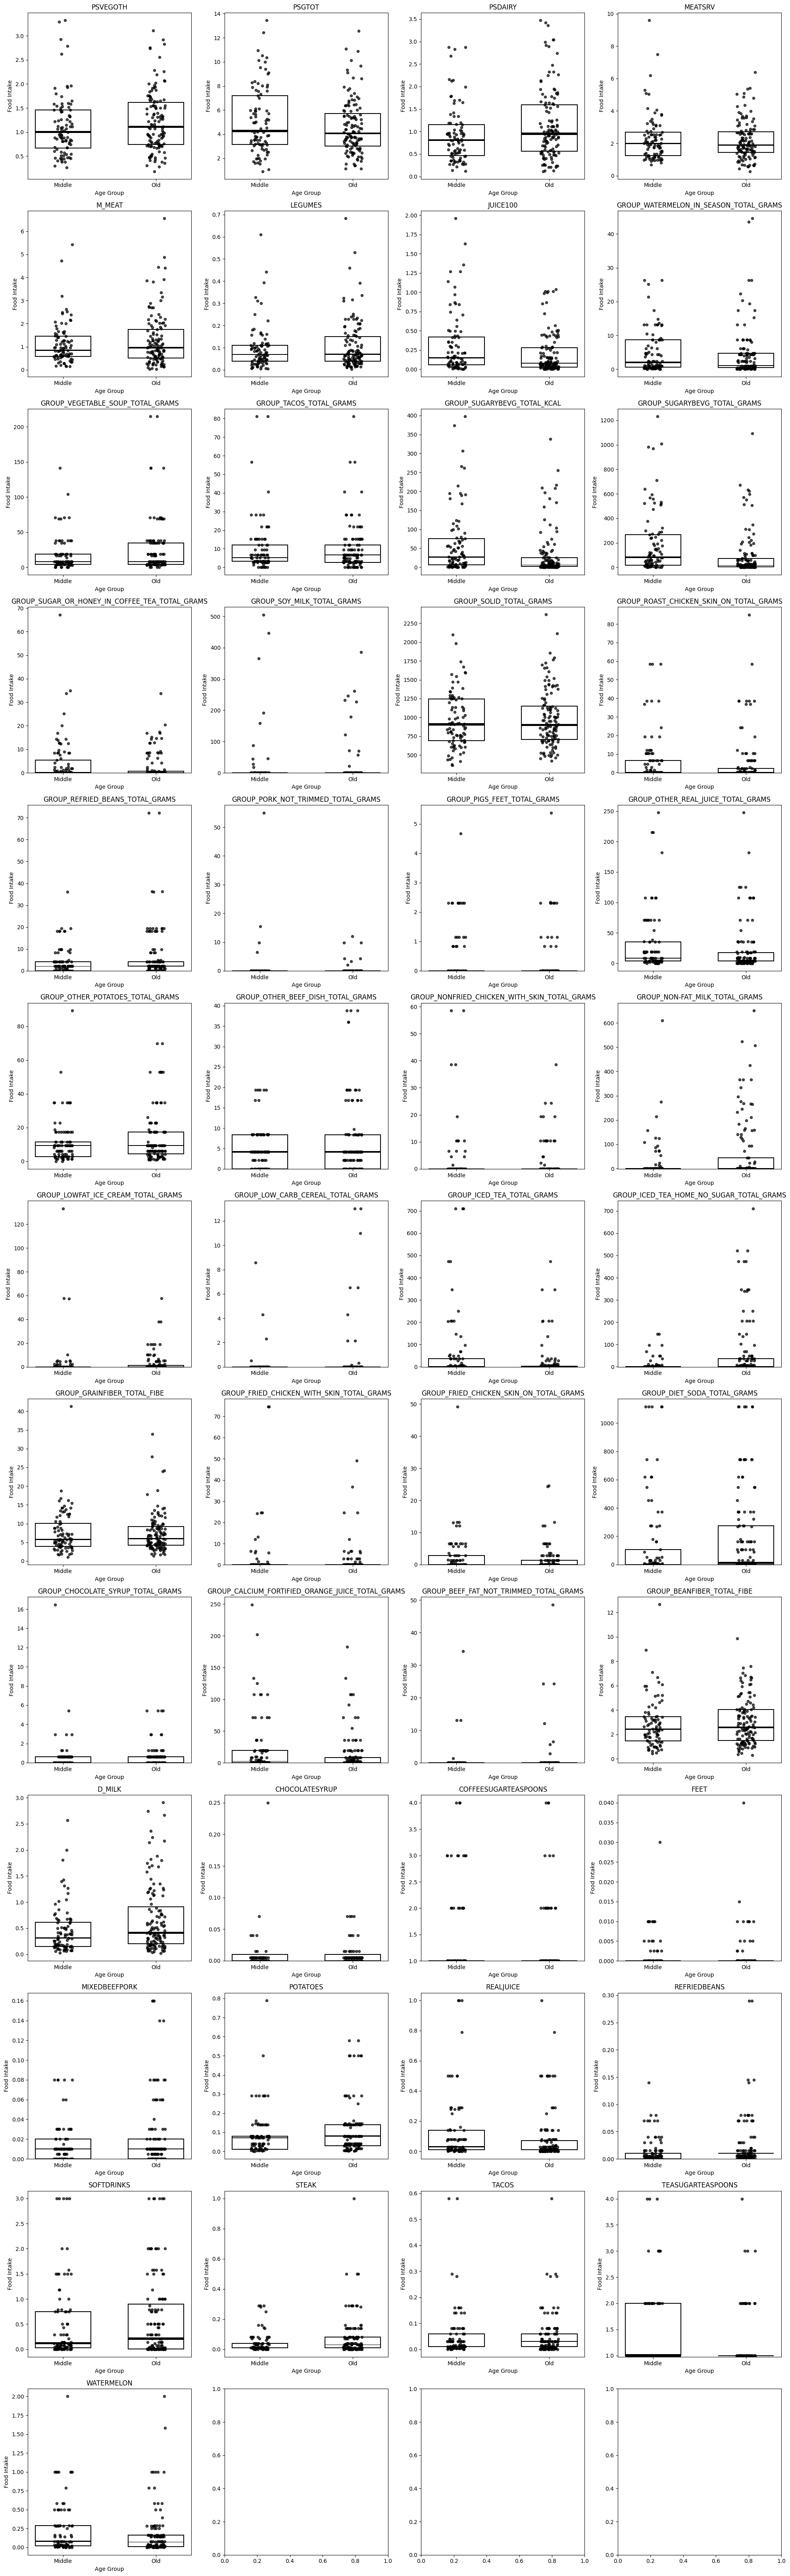

In [119]:
Continuous_Descriptive_Analysis[['Median', 'Q1', 'Q3']] = Continuous_Descriptive_Analysis['Median_IQR'].str.extract(
    r'([\d\.]+) \[([\d\.]+), ([\d\.]+)\]'
).astype(float)

foods_list = Continuous_Descriptive_Analysis['Food'].unique()
n_foods = len(foods_list)

fig, axes = plt.subplots(nrows=(n_foods+3)//4, ncols=4, figsize=(20, 5*((n_foods+3)//4)))
axes = axes.flatten()

for i, food in enumerate(foods_list):
    df_food = Continuous_Descriptive_Analysis[Continuous_Descriptive_Analysis['Food'] == food].sort_values('AGE_GROUP')
    
    for j, age_group in enumerate(df_food['AGE_GROUP']):
        median = df_food['Median'].values[j]
        q1 = df_food['Q1'].values[j]
        q3 = df_food['Q3'].values[j]
        
        axes[i].bar(j, q3 - q1, bottom=q1, color='white', edgecolor='black', linewidth=1.5, width=0.6)
        axes[i].bar(j, 0.05*(q3-q1), bottom=median - 0.025*(q3-q1), color='black', width=0.6)
        original_values = data[data['AGE_GROUP'] == age_group][food].dropna()
        x_jitter = j + (np.random.rand(len(original_values)) - 0.5) * 0.2
        axes[i].scatter(x_jitter, original_values, color='black', alpha=0.7, s=20)
        
    axes[i].set_title(food)
    axes[i].set_ylabel("Food Intake")
    axes[i].set_xlabel("Age Group")
    axes[i].set_xticks(range(len(df_food['AGE_GROUP'])))
    axes[i].set_xticklabels(df_food['AGE_GROUP'])

plt.tight_layout()
plt.show()

In [120]:
Continuous_Regression_Analysis = []

for food in foods:
    for age_group in data['AGE_GROUP'].unique():
        subset = data[data['AGE_GROUP'] == age_group].copy()
        
        subset = subset.dropna(subset=['VB', food])

        if len(subset) > 0:
            subset['ln_VB'] = np.log(subset['VB'])
            
            X = sm.add_constant(subset[food])
            y = subset['ln_VB']
            
            model = sm.OLS(y, X).fit()
            
            if model.pvalues[food] < 0.05:
                Continuous_Regression_Analysis.append({
                    'Food': food,
                    'AGE_GROUP': age_group,
                    'β1': model.params[food],
                    'p-value': model.pvalues[food]})

Continuous_Regression_Analysis = pd.DataFrame(Continuous_Regression_Analysis)
print(Continuous_Regression_Analysis)
Continuous_Regression_Analysis.to_excel("Continuous_Regression_Analysis.xlsx", index=False)

                                              Food AGE_GROUP         β1  \
0                                           PSGTOT       Old   0.115872   
1           GROUP_WATERMELON_IN_SEASON_TOTAL_GRAMS       Old  -0.046138   
2                      GROUP_SUGARYBEVG_TOTAL_KCAL    Middle  -0.004315   
3                     GROUP_SUGARYBEVG_TOTAL_GRAMS    Middle  -0.001178   
4   GROUP_SUGAR_OR_HONEY_IN_COFFEE_TEA_TOTAL_GRAMS       Old  -0.033639   
5                       GROUP_SOY_MILK_TOTAL_GRAMS    Middle  -0.004174   
6          GROUP_ROAST_CHICKEN_SKIN_ON_TOTAL_GRAMS    Middle  -0.025233   
7          GROUP_ROAST_CHICKEN_SKIN_ON_TOTAL_GRAMS       Old  -0.025544   
8                  GROUP_REFRIED_BEANS_TOTAL_GRAMS    Middle   0.046943   
9                      GROUP_GRAINFIBER_TOTAL_FIBE       Old   0.046662   
10                            COFFEESUGARTEASPOONS       Old  -0.429886   
11                                    REFRIEDBEANS    Middle  11.536817   
12                       

(2)-2 Significant Categorical Food Variables (Descriptive Analysis, Ordinary Least Squares Linear Regression)

In [2]:
file_path = r"C:\Users\User\OneDrive - Emory University\Documents\GitHub\BIOS-584\Final Project - Josie\Categorical_Significant.xlsx"
data = pd.read_excel(file_path)
exclude = ['ID', 'VB', 'AGE', 'SEX']
foods = [c for c in data.columns if c not in exclude]

In [3]:
data['AGE_GROUP'] = pd.cut(data['AGE'], bins=[0, 50, 100], labels=['Middle', 'Old'])

In [123]:
Categorical_Descriptive_Analysis = []

for food in foods: 
    for age_group in data['AGE_GROUP'].unique():
        subset = data[data['AGE_GROUP'] == age_group].copy()
        subset = subset.dropna(subset=[food])
        
        if len(subset) > 0:
            counts = subset[food].value_counts()
            
            for cat in counts.index:
                Categorical_Descriptive_Analysis.append({
                    'Food': food,
                    'AGE_GROUP': age_group,
                    'Category': cat,
                    'Count': counts[cat]
                })

Categorical_Descriptive_Analysis = pd.DataFrame(Categorical_Descriptive_Analysis)
print(Categorical_Descriptive_Analysis)
Categorical_Descriptive_Analysis.to_excel("Categorical_Descriptive_Analysis.xlsx", index=False)

               Food AGE_GROUP Category  Count
0          MILKTYPE    Middle        2     42
1          MILKTYPE    Middle        4     17
2          MILKTYPE    Middle        3     14
3          MILKTYPE    Middle        5     10
4          MILKTYPE    Middle        1      6
5          MILKTYPE       Old        2     51
6          MILKTYPE       Old        4     38
7          MILKTYPE       Old        3     15
8          MILKTYPE       Old        5     11
9          MILKTYPE       Old        1      7
10         MILKTYPE       Old        6      2
11     LCCEREALTYPE    Middle        M     85
12     LCCEREALTYPE    Middle        1      4
13     LCCEREALTYPE       Old        M    114
14     LCCEREALTYPE       Old        1     10
15      ICEDTEATYPE    Middle        2     52
16      ICEDTEATYPE    Middle        1     18
17      ICEDTEATYPE    Middle        4     12
18      ICEDTEATYPE    Middle        3      7
19      ICEDTEATYPE       Old        1     57
20      ICEDTEATYPE       Old     

In [4]:
Categorical_Regression_Analysis = []

for food in foods: 
    for age_group in data['AGE_GROUP'].unique():
        subset = data[data['AGE_GROUP'] == age_group].copy()
        subset = subset.dropna(subset=['VB', food])
        
        if len(subset) > 0:
            subset['VB_log'] = np.log10(subset['VB'].astype(float))
            X = pd.get_dummies(subset[food], drop_first=True).astype(float)
            X = sm.add_constant(X)
            y = subset['VB_log']
            
            model = sm.OLS(y, X).fit()
            
            for cat in X.columns[1:]:
                if model.pvalues[cat] < 0.05:
                    Categorical_Regression_Analysis.append({
                        'Food': food,
                        'AGE_GROUP': age_group,
                        'Category': cat,
                        'β': model.params[cat],
                        'p-value': model.pvalues[cat]
                    })

Categorical_Regression_Analysis = pd.DataFrame(Categorical_Regression_Analysis)
print(Categorical_Regression_Analysis)
Categorical_Regression_Analysis.to_excel("Categorical_Regression_Analysis.xlsx", index=False)

              Food AGE_GROUP  Category         β   p-value
0         MILKTYPE       Old         6 -0.721649  0.037890
1      ICEDTEATYPE       Old         2 -0.221490  0.010390
2  CHICKENSKINTYPE    Middle         2 -0.224823  0.046553
3       SUGARINTEA       Old         2 -0.251023  0.004169
4    SUGARINCOFFEE       Old         2 -0.306974  0.000690


Research Question (3): To investigate sex-specific differences in the associations between circulating VB and the identified food items/groups.

Variable 'SEX' is coded either 'Male' or 'Female'.

In [135]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [136]:
file_path = r"C:\Users\User\OneDrive - Emory University\Documents\GitHub\BIOS-584\Final Project - Josie\Continuous_Significant.xlsx"
data = pd.read_excel(file_path)
exclude = ['ID', 'VB', 'AGE', 'SEX']
foods = [c for c in data.columns if c not in exclude]

(3)-1 Significant Continuous Food Variables (Descriptive Analysis, Ordinary Least Squares Linear Regression)

In [137]:
Continuous_Descriptive_Analysis_SEX = []

for food in foods:
    for sex in data['SEX'].unique():  
        subset = data[data['SEX'] == sex].copy()
        subset = subset.dropna(subset=[food])
        
        if len(subset) > 0:
            median = subset[food].median()
            q1 = subset[food].quantile(0.25)
            q3 = subset[food].quantile(0.75)
            
            Continuous_Descriptive_Analysis_SEX.append({
                'Food': food,
                'SEX': sex,
                'Median_IQR': f"{median:.2f} [{q1:.2f}, {q3:.2f}]"
            })
            
Continuous_Descriptive_Analysis_SEX = pd.DataFrame(Continuous_Descriptive_Analysis_SEX)
print(Continuous_Descriptive_Analysis_SEX)
Continuous_Descriptive_Analysis_SEX.to_excel("Continuous_Descriptive_Analysis_SEX.xlsx", index=False)

                 Food     SEX         Median_IQR
0            PSVEGOTH  Female  1.06 [0.73, 1.53]
1            PSVEGOTH    Male  1.11 [0.69, 1.53]
2              PSGTOT  Female  3.76 [2.82, 5.28]
3              PSGTOT    Male  5.94 [4.02, 7.67]
4             PSDAIRY  Female  0.83 [0.50, 1.17]
..                ...     ...                ...
93              TACOS    Male  0.04 [0.01, 0.08]
94  TEASUGARTEASPOONS  Female  1.00 [1.00, 1.00]
95  TEASUGARTEASPOONS    Male  1.00 [1.00, 1.00]
96         WATERMELON  Female  0.08 [0.01, 0.28]
97         WATERMELON    Male  0.03 [0.01, 0.14]

[98 rows x 3 columns]


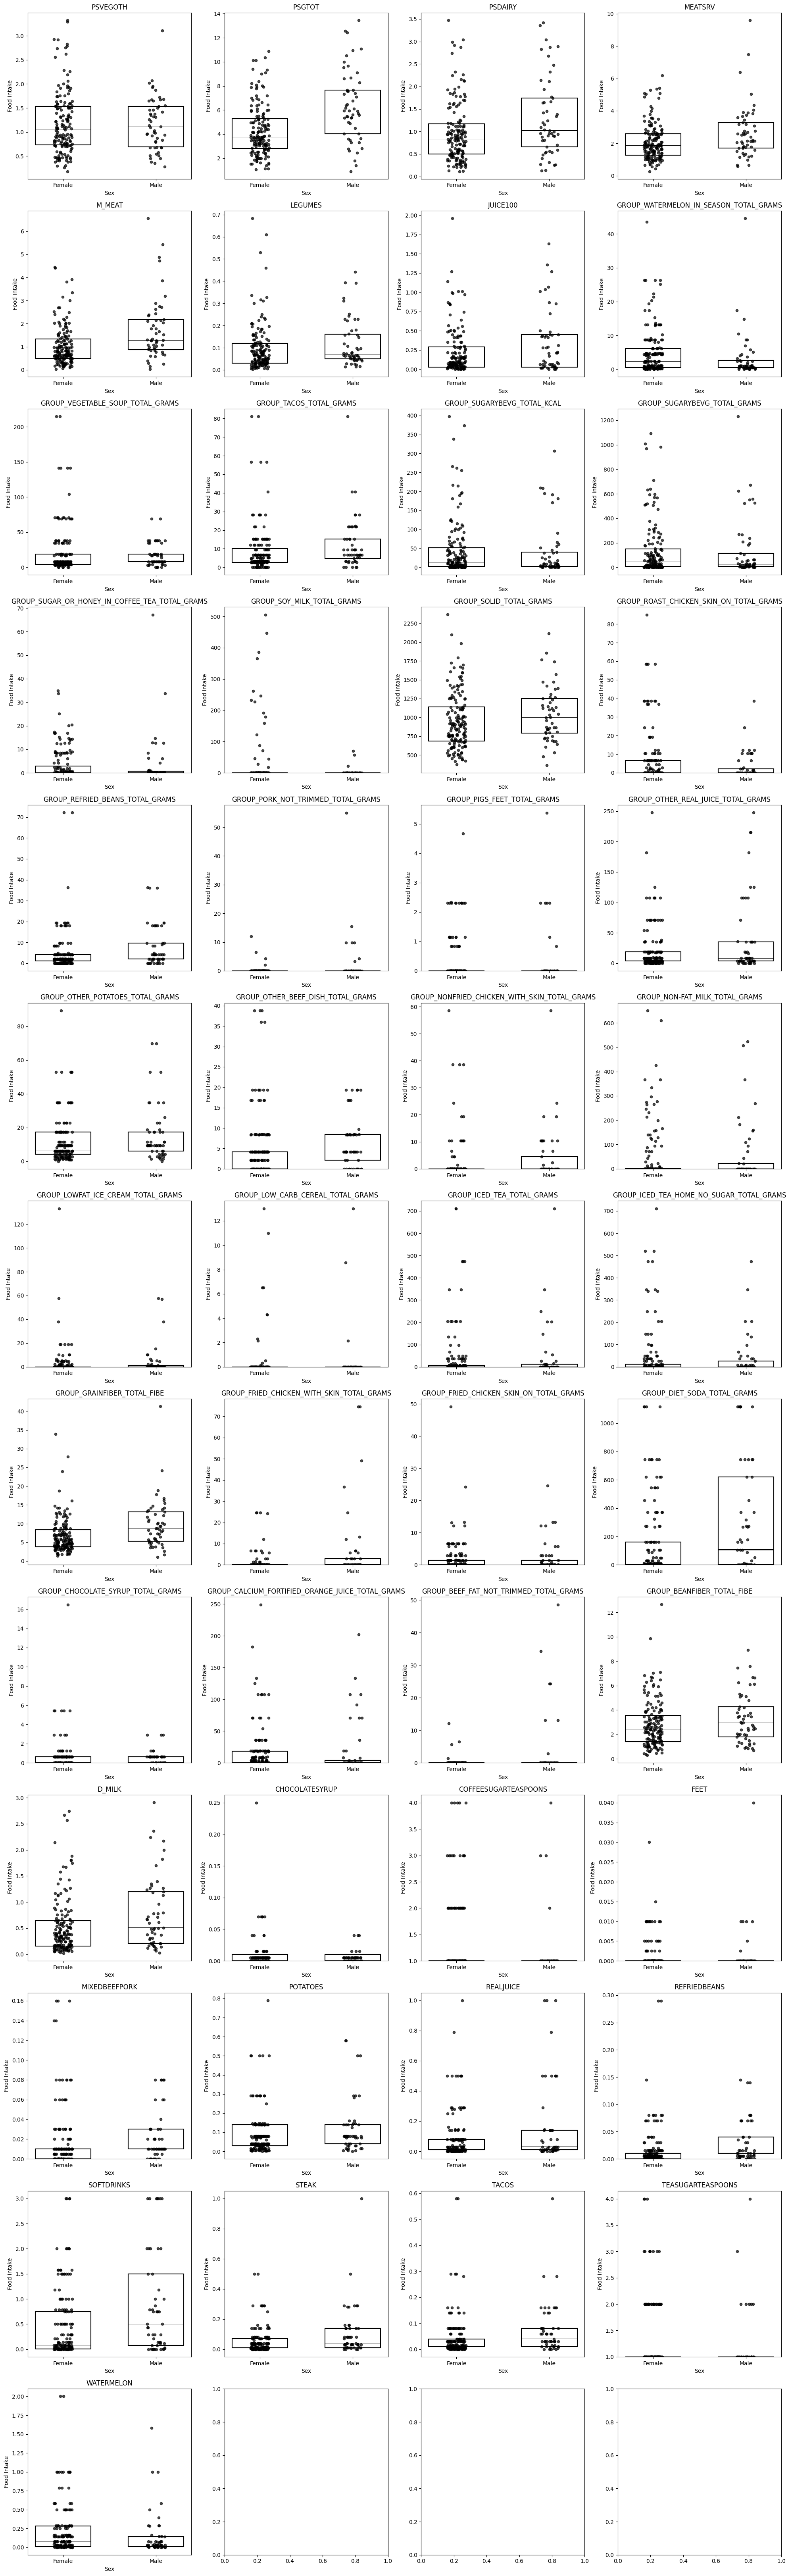

In [138]:
Continuous_Descriptive_Analysis_SEX[['Median', 'Q1', 'Q3']] = Continuous_Descriptive_Analysis_SEX['Median_IQR'].str.extract(
    r'([\d\.]+) \[([\d\.]+), ([\d\.]+)\]'
).astype(float)

foods_list = Continuous_Descriptive_Analysis_SEX['Food'].unique()
n_foods = len(foods_list)

fig, axes = plt.subplots(nrows=(n_foods+3)//4, ncols=4, figsize=(20, 5*((n_foods+3)//4)))
axes = axes.flatten()

for i, food in enumerate(foods_list):
    df_food = Continuous_Descriptive_Analysis_SEX[Continuous_Descriptive_Analysis_SEX['Food'] == food].sort_values('SEX')
    sexes = df_food['SEX'].values

    for j, sex in enumerate(sexes):
        median = df_food['Median'].values[j]
        q1 = df_food['Q1'].values[j]
        q3 = df_food['Q3'].values[j]

        axes[i].bar(j, q3 - q1, bottom=q1, color='white', edgecolor='black', linewidth=1.5, width=0.6)
        axes[i].bar(j, 0.01*(q3-q1), bottom=median - 0.005*(q3-q1), color='black', width=0.6)
        original_values = data[data['SEX'] == sex][food].dropna()
        x_jitter = j + (np.random.rand(len(original_values)) - 0.5) * 0.2
        axes[i].scatter(x_jitter, original_values, color='black', alpha=0.7, s=20)

    axes[i].set_title(food)
    axes[i].set_ylabel("Food Intake")
    axes[i].set_xlabel("Sex")
    axes[i].set_xticks(range(len(sexes)))
    axes[i].set_xticklabels(sexes)

plt.tight_layout()
plt.show()

In [139]:
Continuous_Regression_Analysis_SEX = []

for food in foods:
    for sex in data['SEX'].unique(): 
        subset = data[data['SEX'] == sex].copy()
        subset = subset.dropna(subset=['VB', food])

        if len(subset) > 0:
            subset['ln_VB'] = np.log(subset['VB'])
            
            X = sm.add_constant(subset[food])
            y = subset['ln_VB']
            
            model = sm.OLS(y, X).fit()
            
            if model.pvalues[food] < 0.05:
                Continuous_Regression_Analysis_SEX.append({
                    'Food': food,
                    'SEX': sex,
                    'β1': model.params[food],
                    'p-value': model.pvalues[food]
                })

Continuous_Regression_Analysis_SEX = pd.DataFrame(Continuous_Regression_Analysis_SEX)
print(Continuous_Regression_Analysis_SEX)
Continuous_Regression_Analysis_SEX.to_excel("Continuous_Regression_Analysis_SEX.xlsx", index=False)

                                        Food     SEX        β1   p-value
0                                   PSVEGOTH    Male  0.382676  0.001562
1                                     PSGTOT  Female  0.090136  0.049637
2                                    PSDAIRY  Female  0.364952  0.012554
3     GROUP_WATERMELON_IN_SEASON_TOTAL_GRAMS  Female -0.039951  0.003959
4     GROUP_WATERMELON_IN_SEASON_TOTAL_GRAMS    Male -0.039162  0.000036
5                GROUP_SUGARYBEVG_TOTAL_KCAL  Female -0.004207  0.001385
6               GROUP_SUGARYBEVG_TOTAL_GRAMS  Female -0.001447  0.001143
7                 GROUP_SOY_MILK_TOTAL_GRAMS  Female -0.002736  0.023086
8                    GROUP_SOLID_TOTAL_GRAMS    Male  0.000481  0.009754
9    GROUP_ROAST_CHICKEN_SKIN_ON_TOTAL_GRAMS  Female -0.027962  0.000020
10           GROUP_REFRIED_BEANS_TOTAL_GRAMS    Male  0.015233  0.035861
11        GROUP_OTHER_REAL_JUICE_TOTAL_GRAMS  Female -0.007718  0.004882
12  GROUP_ICED_TEA_HOME_NO_SUGAR_TOTAL_GRAMS  Femal

(3)-2 Significant Categorical Food Variables (Descriptive Analysis, Ordinary Least Squares Linear Regression)

In [5]:
file_path = r"C:\Users\User\OneDrive - Emory University\Documents\GitHub\BIOS-584\Final Project - Josie\Categorical_Significant.xlsx"
data = pd.read_excel(file_path)
exclude = ['ID', 'VB', 'AGE', 'SEX']
foods = [c for c in data.columns if c not in exclude]

In [141]:
Categorical_Descriptive_Analysis_SEX = []

for food in foods: 
    for sex in data['SEX'].unique(): 
        subset = data[data['SEX'] == sex].copy()
        subset = subset.dropna(subset=[food])
        
        if len(subset) > 0:
            counts = subset[food].value_counts()
            total = len(subset)
            
            for cat in counts.index:
                Categorical_Descriptive_Analysis_SEX.append({
                    'Food': food,
                    'SEX': sex,
                    'Category': cat,
                    'Count': counts[cat],
                })

Categorical_Descriptive_Analysis_SEX = pd.DataFrame(Categorical_Descriptive_Analysis_SEX)
print(Categorical_Descriptive_Analysis_SEX)
Categorical_Descriptive_Analysis_SEX.to_excel("Categorical_Descriptive_Analysis_SEX.xlsx", index=False)

               Food     SEX Category  Count
0          MILKTYPE  Female        2     69
1          MILKTYPE  Female        4     40
2          MILKTYPE  Female        3     22
3          MILKTYPE  Female        5     18
4          MILKTYPE  Female        1      9
5          MILKTYPE  Female        6      2
6          MILKTYPE    Male        2     24
7          MILKTYPE    Male        4     15
8          MILKTYPE    Male        3      7
9          MILKTYPE    Male        1      4
10         MILKTYPE    Male        5      3
11     LCCEREALTYPE  Female        M    149
12     LCCEREALTYPE  Female        1     11
13     LCCEREALTYPE    Male        M     50
14     LCCEREALTYPE    Male        1      3
15      ICEDTEATYPE  Female        2     78
16      ICEDTEATYPE  Female        1     54
17      ICEDTEATYPE  Female        3     16
18      ICEDTEATYPE  Female        4     12
19      ICEDTEATYPE    Male        1     21
20      ICEDTEATYPE    Male        2     21
21      ICEDTEATYPE    Male     

In [6]:
Categorical_Regression_Analysis_SEX = []

for food in foods: 
    for sex in data['SEX'].unique(): 
        subset = data[data['SEX'] == sex].copy()
        subset = subset.dropna(subset=[food, 'VB'])
        
        if len(subset) > 0:
            subset['VB_log'] = np.log10(subset['VB'].astype(float))
            X = pd.get_dummies(subset[food], drop_first=True).astype(float)
            X = sm.add_constant(X)
            y = subset['VB_log']
            
            model = sm.OLS(y, X).fit()
            
            for cat in X.columns[1:]: 
                if model.pvalues[cat] < 0.05: 
                    Categorical_Regression_Analysis_SEX.append({
                        'Food': food,
                        'SEX': sex,
                        'Category': cat,
                        'β': model.params[cat],
                        'p-value': model.pvalues[cat]
                    })

Categorical_Regression_Analysis_SEX = pd.DataFrame(Categorical_Regression_Analysis_SEX)
print(Categorical_Regression_Analysis_SEX)
Categorical_Regression_Analysis_SEX.to_excel("Categorical_Regression_Analysis_SEX.xlsx", index=False)

              Food     SEX  Category         β   p-value
0         MILKTYPE  Female         3  0.518158  0.010878
1         MILKTYPE  Female         4  0.448253  0.017971
2      ICEDTEATYPE  Female         2 -0.309622  0.000758
3    FATONMEATTYPE    Male         3  0.185005  0.038906
4  CHICKENSKINTYPE  Female         2 -0.261608  0.002965
5       SUGARINTEA  Female         2 -0.299238  0.000392
6    SUGARINCOFFEE  Female         2 -0.314820  0.000557
